In [23]:
import pandas as pd

In [24]:
import polars as pl

In [25]:
from datetime import datetime, time

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize']=(20, 6)

In [27]:
sunshine = pd.read_csv('/total_sunshine_data.csv')

In [28]:
sunshine['Datum'] = pd.to_datetime(sunshine['Datum'])

In [29]:
type(sunshine['Tid (UTC)'][0])

str

In [30]:
sunshine.sample(5)

,Datum,Tid (UTC),Solskenstid,Kvalitet
95360,2023-09-19,21:00:00,0,G
42099,2023-02-20,13:00:00,198,G
18490,2022-04-12,03:00:00,0,G
96751,2022-01-16,13:00:00,0,G
25778,2023-02-09,19:00:00,0,G


In [31]:
sunshine.dtypes

Datum          datetime64[ns]
Tid (UTC)              object
Solskenstid             int64
Kvalitet               object
dtype: object

In [32]:
sunshine['Tid (UTC)'] = pd.to_datetime(sunshine['Tid (UTC)'], format='%H:%M:%S').dt.time

In [33]:
sun_intensity = sunshine.copy()

In [34]:
sun_intensity['datewithtime'] = sun_intensity.apply(lambda row: datetime.combine(row['Datum'].date(), row['Tid (UTC)']), axis=1)

In [35]:
sun_intensity.shape

(144543, 5)

In [36]:
sun_intensity.head()

,Datum,Tid (UTC),Solskenstid,Kvalitet,datewithtime
0,2022-01-01,00:00:00,0,G,2022-01-01 00:00:00
1,2022-01-01,01:00:00,0,G,2022-01-01 01:00:00
2,2022-01-01,02:00:00,0,G,2022-01-01 02:00:00
3,2022-01-01,03:00:00,0,G,2022-01-01 03:00:00
4,2022-01-01,04:00:00,0,G,2022-01-01 04:00:00


In [37]:
sun_intensity = sun_intensity.rename(columns = {'Datum':'Date', 'Tid (UTC)' : 'Time(UTC)', 'Solskenstid' : 'Sunshinewithtime', 'Kvalitet' : 'Quality'})

In [38]:
sun_intensity.columns

Index(['Date', 'Time(UTC)', 'Sunshinewithtime', 'Quality', 'datewithtime'], dtype='object')

In [39]:
sun_intensity['datewithtime'].agg(['min', 'max']) # We have the data from 2022-01-01 00:00:00 to 2023-11-01 06:00:00 around 22 months

min   2022-01-01 00:00:00
max   2023-11-01 06:00:00
Name: datewithtime, dtype: datetime64[ns]

In [40]:
sun_intensity['Quality'].unique() # There are two power generation results according to sunlight intensity

array(['G', 'Y'], dtype=object)

In [41]:
sun_intensity['Sunshinewithtime'].agg(['max', 'min', 'nunique', 'mean', 'median'])

max        3600.000000
min           0.000000
nunique    3593.000000
mean        942.504383
median        0.000000
Name: Sunshinewithtime, dtype: float64

<Axes: xlabel='Sunshinewithtime', ylabel='datewithtime'>

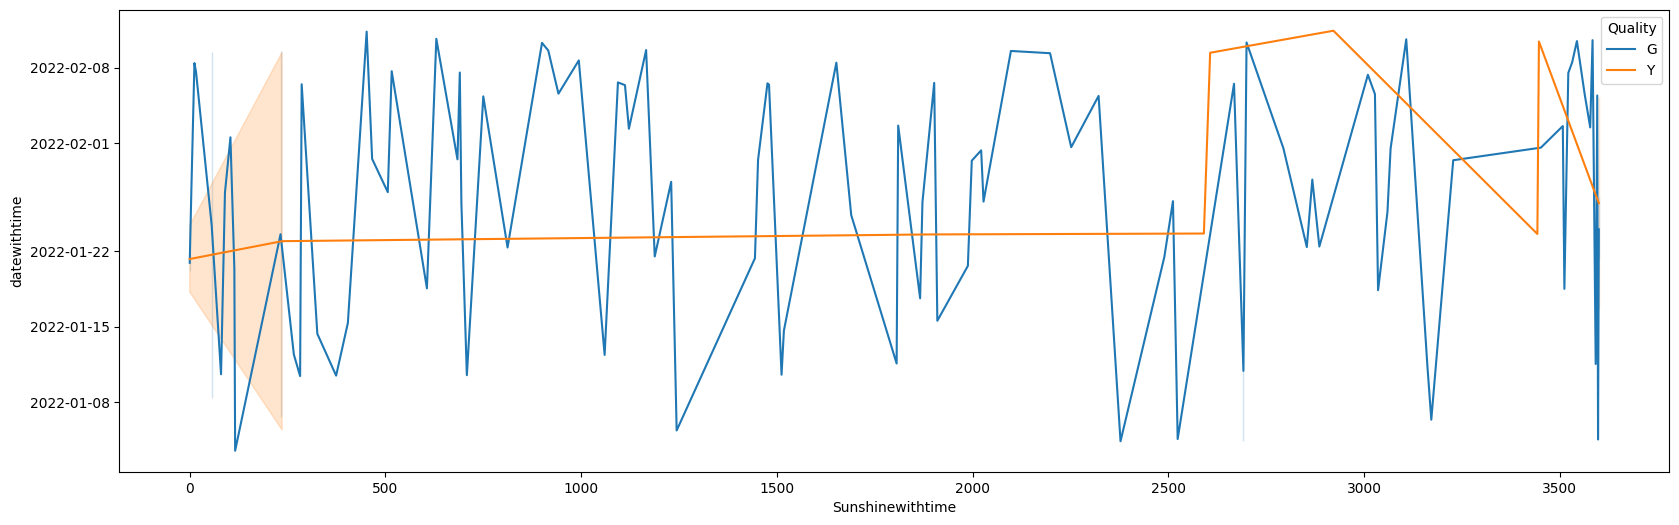

In [42]:
sns.lineplot(data=sun_intensity.head(1000), x='Sunshinewithtime', y = 'datewithtime', hue = 'Quality')

In [43]:
sun_intensity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144543 entries, 0 to 144542
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Date              144543 non-null  datetime64[ns]
 1   Time(UTC)         144543 non-null  object        
 2   Sunshinewithtime  144543 non-null  int64         
 3   Quality           144543 non-null  object        
 4   datewithtime      144543 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(2)
memory usage: 5.5+ MB


In [44]:
sun_intensity.describe()

,Sunshinewithtime
count,144543.000000
mean,942.504383
std,1453.023989
min,0.000000
25%,0.000000
50%,0.000000
75%,2028.000000
max,3600.000000


In [45]:
sun_intensity[sun_intensity.duplicated()].sample(10)

,Date,Time(UTC),Sunshinewithtime,Quality,datewithtime
71180,2022-10-16,16:00:00,0,G,2022-10-16 16:00:00
135624,2022-10-24,16:00:00,0,G,2022-10-24 16:00:00
103975,2022-11-13,13:00:00,0,G,2022-11-13 13:00:00
47506,2023-10-03,20:00:00,0,G,2023-10-03 20:00:00
91076,2023-03-25,09:00:00,0,G,2023-03-25 09:00:00
54041,2022-09-01,20:00:00,0,G,2022-09-01 20:00:00
82907,2022-04-19,00:00:00,0,G,2022-04-19 00:00:00
109084,2023-06-14,10:00:00,3600,G,2023-06-14 10:00:00
115841,2022-05-22,16:00:00,3600,G,2022-05-22 16:00:00
104383,2022-11-30,13:00:00,0,G,2022-11-30 13:00:00


In [46]:
sun_intensity.duplicated().value_counts()

True     92081
False    52462
dtype: int64

In [47]:
# sun_intensity.drop_duplicates().loc[sun_intensity['datewithtime'] == '2022-03-27 17:00:00']
sun_intensity = sun_intensity.drop_duplicates()

In [48]:
sun_intensity.shape

(52462, 5)

In [49]:
Day_avg_sunlight_intensity = sun_intensity.groupby(sun_intensity['datewithtime'].dt.date)['Sunshinewithtime'].mean()

In [50]:
type(Day_avg_sunlight_intensity)

pandas.core.series.Series

In [51]:
Day_avg_sunlight_intensity

datewithtime
2022-01-01     152.787879
2022-01-02       0.000000
2022-01-03     225.242424
2022-01-04    1346.753846
2022-01-05     616.350000
                 ...     
2023-10-28     251.882353
2023-10-29     861.302326
2023-10-30      34.093750
2023-10-31       0.000000
2023-11-01       0.000000
Name: Sunshinewithtime, Length: 670, dtype: float64

In [52]:
Day_avg_sunlight_intensity.values

array([1.52787879e+02, 0.00000000e+00, 2.25242424e+02, 1.34675385e+03,
       6.16350000e+02, 1.29407937e+03, 7.80216216e+02, 1.92758621e+01,
       1.40675000e+02, 8.62089286e+02, 1.04946512e+03, 3.64911111e+02,
       5.25324324e+02, 1.52685965e+03, 1.24032692e+03, 2.43764706e+02,
       1.43420312e+03, 1.05687500e+03, 1.56103448e+02, 1.12108000e+03,
       1.05651471e+03, 3.36266667e+02, 5.29740741e+02, 9.99588235e+02,
       1.62003774e+03, 1.01998148e+03, 2.82479167e+02, 1.29757143e+03,
       7.94516129e+01, 9.87457143e+02, 1.28159016e+03, 4.68052632e+02,
       1.02932877e+03, 4.58869565e+02, 1.64516129e+00, 1.81094937e+03,
       1.36401235e+03, 1.41405970e+03, 1.18812857e+03, 1.24196591e+03,
       1.67204167e+03, 1.33741379e+03, 7.88894737e+02, 8.09117647e+01,
       1.11470588e+01, 7.73371795e+02, 9.11425000e+02, 8.21777778e+02,
       1.46264286e+03, 1.36221875e+03, 1.45717742e+03, 1.63366667e+02,
       8.99766667e+02, 1.07856944e+03, 9.69985294e+02, 1.41376667e+03,
      

In [53]:
sun_intensity = sun_intensity.merge(Day_avg_sunlight_intensity,
                                    left_on=sun_intensity['datewithtime'].dt.date, right_index=True)

In [54]:
sun_intensity.head()

,key_0,Date,Time(UTC),Sunshinewithtime_x,Quality,datewithtime,Sunshinewithtime_y
0,2022-01-01,2022-01-01,00:00:00,0,G,2022-01-01 00:00:00,152.787879
1,2022-01-01,2022-01-01,01:00:00,0,G,2022-01-01 01:00:00,152.787879
2,2022-01-01,2022-01-01,02:00:00,0,G,2022-01-01 02:00:00,152.787879
3,2022-01-01,2022-01-01,03:00:00,0,G,2022-01-01 03:00:00,152.787879
4,2022-01-01,2022-01-01,04:00:00,0,G,2022-01-01 04:00:00,152.787879


In [55]:
# sun_intensity.loc[sun_intensity['Date'] == '2022-01-03'] --> Hence True
sun_intensity_mean_of_day = sun_intensity.drop_duplicates(subset='Sunshinewithtime_y')

In [56]:
sun_intensity_mean = sun_intensity_mean_of_day.drop(['key_0', 'Sunshinewithtime_x', 'Time(UTC)', 'datewithtime'], axis=1)

In [57]:
sun_intensity_mean = sun_intensity_mean.rename(columns={'Sunshinewithtime_y':'Sunshinewithtime'})

In [58]:
sun_intensity_mean

,Date,Quality,Sunshinewithtime
0,2022-01-01,G,152.787879
24,2022-01-02,G,0.000000
48,2022-01-03,G,225.242424
72,2022-01-04,G,1346.753846
96,2022-01-05,G,616.350000
...,...,...,...
15912,2023-10-26,G,8.558140
15936,2023-10-27,G,2.107143
15960,2023-10-28,G,251.882353
15984,2023-10-29,G,861.302326


In [59]:
from imblearn.over_sampling import SMOTE # Synthetic Minority Over-sampling Technique
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
smote = SMOTE()

In [60]:
from sklearn.utils import resample

In [61]:
sun_intensity_mean['Date_Float'] = sun_intensity_mean['Date'].astype('int64') / 10**9  # Convert to Unix timestamp in seconds


In [62]:
sun_intensity_mean

,Date,Quality,Sunshinewithtime,Date_Float
0,2022-01-01,G,152.787879,1.640995e+09
24,2022-01-02,G,0.000000,1.641082e+09
48,2022-01-03,G,225.242424,1.641168e+09
72,2022-01-04,G,1346.753846,1.641254e+09
96,2022-01-05,G,616.350000,1.641341e+09
...,...,...,...,...
15912,2023-10-26,G,8.558140,1.698278e+09
15936,2023-10-27,G,2.107143,1.698365e+09
15960,2023-10-28,G,251.882353,1.698451e+09
15984,2023-10-29,G,861.302326,1.698538e+09


In [63]:
Y_sample_x = sun_intensity_mean[['Sunshinewithtime', 'Date_Float']]
Y_sample_y = sun_intensity_mean[['Quality']]

In [64]:
X_resampled, y_resampled = ros.fit_resample(Y_sample_x, Y_sample_y)

In [65]:
X_resampled['Date'] = pd.to_datetime(X_resampled['Date_Float'], unit='s')

In [66]:
X_resampled

,Sunshinewithtime,Date_Float,Date
0,152.787879,1.640995e+09,2022-01-01
1,0.000000,1.641082e+09,2022-01-02
2,225.242424,1.641168e+09,2022-01-03
3,1346.753846,1.641254e+09,2022-01-04
4,616.350000,1.641341e+09,2022-01-05
...,...,...,...
1219,1705.378788,1.645834e+09,2022-02-26
1220,1447.929293,1.678406e+09,2023-03-10
1221,2140.750000,1.687738e+09,2023-06-26
1222,2152.362832,1.688774e+09,2023-07-08


In [67]:
y_resampled

,Quality
0,G
1,G
2,G
3,G
4,G
...,...
1219,Y
1220,Y
1221,Y
1222,Y


In [68]:
sun_intensity_mean_sampled = pd.merge(X_resampled, y_resampled, left_index = True, right_index=True)

In [69]:
sun_intensity_mean_sampled = sun_intensity_mean_sampled.drop('Date_Float', axis =1)

In [70]:
sun_intensity_mean_sampled.sample(5)

,Sunshinewithtime,Date,Quality
863,1880.695652,2022-04-19,Y
69,1915.404255,2022-03-11,G
386,1267.345455,2023-02-02,G
39,1241.965909,2022-02-09,G
1076,152.829787,2023-02-16,Y


In [71]:
sun_intensity_mean_sampled.dtypes

Sunshinewithtime           float64
Date                datetime64[ns]
Quality                     object
dtype: object

In [72]:
sun_intensity_mean_sampled['Next_day'] = sun_intensity_mean_sampled['Date']+pd.DateOffset(days=1)

In [73]:
sun_intensity_mean_sampled

,Sunshinewithtime,Date,Quality,Next_day
0,152.787879,2022-01-01,G,2022-01-02
1,0.000000,2022-01-02,G,2022-01-03
2,225.242424,2022-01-03,G,2022-01-04
3,1346.753846,2022-01-04,G,2022-01-05
4,616.350000,2022-01-05,G,2022-01-06
...,...,...,...,...
1219,1705.378788,2022-02-26,Y,2022-02-27
1220,1447.929293,2023-03-10,Y,2023-03-11
1221,2140.750000,2023-06-26,Y,2023-06-27
1222,2152.362832,2023-07-08,Y,2023-07-09


In [74]:
sun_intensity_mean_sampled = sun_intensity_mean_sampled.sort_values(by='Date')

In [75]:
sun_intensity_mean_sampled

,Sunshinewithtime,Date,Quality,Next_day
0,152.787879,2022-01-01,G,2022-01-02
1,0.000000,2022-01-02,G,2022-01-03
2,225.242424,2022-01-03,G,2022-01-04
3,1346.753846,2022-01-04,G,2022-01-05
4,616.350000,2022-01-05,G,2022-01-06
...,...,...,...,...
650,8.558140,2023-10-26,G,2023-10-27
651,2.107143,2023-10-27,G,2023-10-28
652,251.882353,2023-10-28,G,2023-10-29
653,861.302326,2023-10-29,G,2023-10-30


In [76]:
sun_intensity_mean_sampled['Next_sun_intensity'] = sun_intensity_mean_sampled['Sunshinewithtime'].shift(-1)

In [77]:
# sun_intensity_mean.loc[sun_intensity_mean['Quality'] == 'Y']['Sunshinewithtime']

In [78]:
sun_intensity_mean_sampled['Next_Quality'] = sun_intensity_mean_sampled['Quality'].shift(-1)

In [79]:
sun_intensity_mean_sampled['Next_Quality'].value_counts()

Y    612
G    611
Name: Next_Quality, dtype: int64

In [80]:
sun_intensity_mean_sampled['Next_Quality'] = sun_intensity_mean_sampled['Next_Quality'].fillna('Y')

In [81]:
sun_intensity_mean_sampled['Next_sun_intensity'] = sun_intensity_mean_sampled['Next_sun_intensity'].fillna(1000)

In [82]:
sun_intensity_mean_sampled[sun_intensity_mean_sampled['Next_Quality'] == 'Y'].sample()

,Sunshinewithtime,Date,Quality,Next_day,Next_sun_intensity,Next_Quality
892,1924.797297,2023-03-15,Y,2023-03-16,1924.797297,Y


In [83]:
sun_intensity_mean_sampled

,Sunshinewithtime,Date,Quality,Next_day,Next_sun_intensity,Next_Quality
0,152.787879,2022-01-01,G,2022-01-02,0.000000,G
1,0.000000,2022-01-02,G,2022-01-03,225.242424,G
2,225.242424,2022-01-03,G,2022-01-04,1346.753846,G
3,1346.753846,2022-01-04,G,2022-01-05,616.350000,G
4,616.350000,2022-01-05,G,2022-01-06,1294.079365,G
...,...,...,...,...,...,...
650,8.558140,2023-10-26,G,2023-10-27,2.107143,G
651,2.107143,2023-10-27,G,2023-10-28,251.882353,G
652,251.882353,2023-10-28,G,2023-10-29,861.302326,G
653,861.302326,2023-10-29,G,2023-10-30,34.093750,G


In [84]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error as MSE #MSE
from sklearn.metrics import mean_absolute_error as MAE # MAE
from sklearn.metrics import r2_score as R2 #R2

In [85]:
sun_intensity_mean_sampled_a = sun_intensity_mean_sampled.sort_values('Date')

In [86]:
sun_intensity_mean_sampled_a['weekday_td'] =  sun_intensity_mean_sampled_a['Date'].dt.dayofweek
sun_intensity_mean_sampled_a['weekday_tm'] =  sun_intensity_mean_sampled_a['Next_day'].dt.dayofweek

In [87]:
sun_intensity_mean_sampled_a

,Sunshinewithtime,Date,Quality,Next_day,Next_sun_intensity,Next_Quality,weekday_td,weekday_tm
0,152.787879,2022-01-01,G,2022-01-02,0.000000,G,5,6
1,0.000000,2022-01-02,G,2022-01-03,225.242424,G,6,0
2,225.242424,2022-01-03,G,2022-01-04,1346.753846,G,0,1
3,1346.753846,2022-01-04,G,2022-01-05,616.350000,G,1,2
4,616.350000,2022-01-05,G,2022-01-06,1294.079365,G,2,3
...,...,...,...,...,...,...,...,...
650,8.558140,2023-10-26,G,2023-10-27,2.107143,G,3,4
651,2.107143,2023-10-27,G,2023-10-28,251.882353,G,4,5
652,251.882353,2023-10-28,G,2023-10-29,861.302326,G,5,6
653,861.302326,2023-10-29,G,2023-10-30,34.093750,G,6,0


In [88]:
import numpy as np

In [89]:
X_var = sun_intensity_mean_sampled_a[['Sunshinewithtime', 'weekday_td', 'Next_sun_intensity']]
y_var = np.where(sun_intensity_mean_sampled_a.Quality.values== 'G', 1, 0)

In [90]:
# Use numpy.unique to get the unique values and their counts
unique_values, value_counts = np.unique(y_var, return_counts=True)
value_counts

array([612, 612])

In [91]:
X_train, X_test, y_train, y_test = train_test_split(X_var, y_var, test_size=0.2, random_state=42)

In [92]:
Lmodel = LogisticRegression()
Lmodel.fit(X_train, y_train)

LogisticRegression()

In [93]:
y_pred = Lmodel.predict(X_test)

In [94]:
mean_sq_err = MSE(y_test, y_pred)
rt_mean_sq_err = np.sqrt(mean_sq_err)
r2_s = R2(y_test, y_pred)
mean_ab_err = MAE(y_test, y_pred)

In [95]:
mean_sq_err, rt_mean_sq_err, r2_s, mean_ab_err

(0.45714285714285713,
 0.6761234037828132,
 -0.8300653594771237,
 0.45714285714285713)

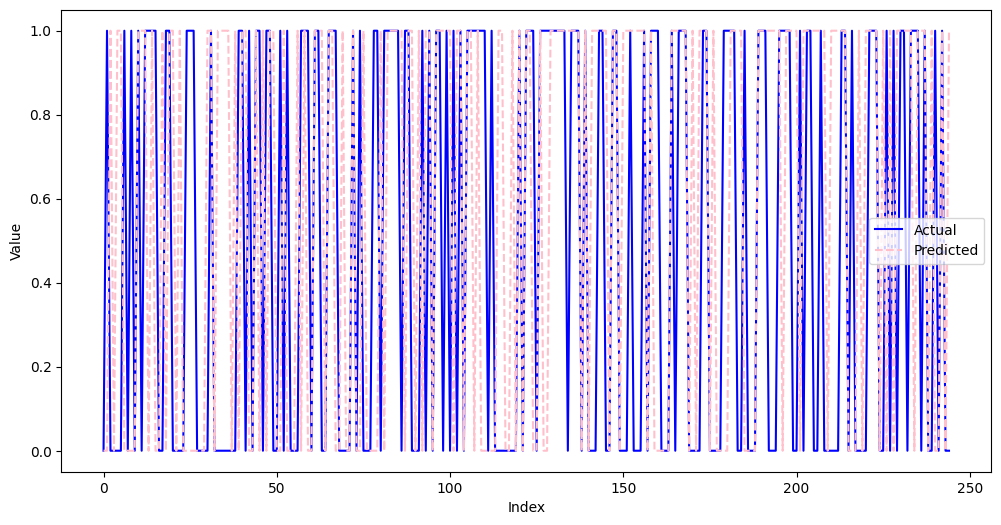

In [96]:
plt.figure(figsize=(12, 6))
# Create an array of indices for the x-axis
x_values = np.arange(len(y_test))

# Plot the actual values as a blue line
plt.plot(x_values, y_test, label='Actual', color='blue')

# Plot the predicted values as a red dashed line
plt.plot(x_values, y_pred, label='Predicted', linestyle='--', color='pink')

# Add labels and legend
plt.xlabel('Index')
plt.ylabel('Value')
plt.legend()

# Show the plot
plt.show()


In [97]:
td_intensity = sun_intensity_mean_sampled_a['Sunshinewithtime'].iloc[-1]
tmrw_intensity=sun_intensity_mean_sampled_a['Next_sun_intensity'].iloc[-1]
wkday = sun_intensity_mean_sampled_a['weekday_td'].iloc[-1]
feature_names = ['Sunshinewithtime', 'weekday_td', 'Next_sun_intensity']
to_pred = pd.DataFrame([[td_intensity, wkday, tmrw_intensity]], columns=feature_names)


In [98]:
n=Lmodel.predict(to_pred)

In [99]:
print(n)
np.where(n == 1, 'G', 'Y')

[1]


array(['G'], dtype='<U1')

In [100]:
# Xgboost time series to regression

In [101]:
# our dataset
sun_intensity_mean_sampled

,Sunshinewithtime,Date,Quality,Next_day,Next_sun_intensity,Next_Quality
0,152.787879,2022-01-01,G,2022-01-02,0.000000,G
1,0.000000,2022-01-02,G,2022-01-03,225.242424,G
2,225.242424,2022-01-03,G,2022-01-04,1346.753846,G
3,1346.753846,2022-01-04,G,2022-01-05,616.350000,G
4,616.350000,2022-01-05,G,2022-01-06,1294.079365,G
...,...,...,...,...,...,...
650,8.558140,2023-10-26,G,2023-10-27,2.107143,G
651,2.107143,2023-10-27,G,2023-10-28,251.882353,G
652,251.882353,2023-10-28,G,2023-10-29,861.302326,G
653,861.302326,2023-10-29,G,2023-10-30,34.093750,G


In [102]:
# Extract data from date column
sun_intensity_mean_sampled_xg = sun_intensity_mean_sampled.drop(['Next_day', 'Next_sun_intensity', 'Next_Quality'], axis=1)
sun_intensity_mean_sampled_xg.dtypes

Sunshinewithtime           float64
Date                datetime64[ns]
Quality                     object
dtype: object

In [103]:
sun_intensity_mean_sampled_xg['weekday'] = sun_intensity_mean_sampled_xg['Date'].dt.dayofweek
sun_intensity_mean_sampled_xg['quarter'] = sun_intensity_mean_sampled_xg['Date'].dt.quarter
sun_intensity_mean_sampled_xg['monthday'] = sun_intensity_mean_sampled_xg['Date'].dt.day
sun_intensity_mean_sampled_xg['month'] = sun_intensity_mean_sampled_xg['Date'].dt.month
sun_intensity_mean_sampled_xg['year'] = sun_intensity_mean_sampled_xg['Date'].dt.year
sun_intensity_mean_sampled_xg['yearday'] = sun_intensity_mean_sampled_xg['Date'].dt.dayofyear
sun_intensity_mean_sampled_xg['sin_year_day'] = np.sin(sun_intensity_mean_sampled_xg['yearday'])
sun_intensity_mean_sampled_xg['cos_year_day'] = np.cos(sun_intensity_mean_sampled_xg['yearday'])

In [104]:
sun_intensity_mean_sampled_xg.drop('Date', axis=1, inplace=True)

In [105]:
sun_intensity_mean_sampled_xg

,Sunshinewithtime,Quality,weekday,quarter,monthday,month,year,yearday,sin_year_day,cos_year_day
0,152.787879,G,5,1,1,1,2022,1,0.841471,0.540302
1,0.000000,G,6,1,2,1,2022,2,0.909297,-0.416147
2,225.242424,G,0,1,3,1,2022,3,0.141120,-0.989992
3,1346.753846,G,1,1,4,1,2022,4,-0.756802,-0.653644
4,616.350000,G,2,1,5,1,2022,5,-0.958924,0.283662
...,...,...,...,...,...,...,...,...,...,...
650,8.558140,G,3,4,26,10,2023,299,-0.521577,-0.853204
651,2.107143,G,4,4,27,10,2023,300,-0.999756,-0.022097
652,251.882353,G,5,4,28,10,2023,301,-0.558764,0.829327
653,861.302326,G,6,4,29,10,2023,302,0.395953,0.918271


In [106]:
sun_intensity_mean_sampled_xg['year'].unique()

array([2022, 2023])

In [107]:
Xg_var = sun_intensity_mean_sampled_xg[['Sunshinewithtime', 'weekday', 'quarter', 'month', 'monthday', 'year', 'yearday', 'sin_year_day', 'cos_year_day']]
yg_var = np.where(sun_intensity_mean_sampled_xg.Quality.values== 'G', 1, 0)

In [108]:
Xg_train, Xg_test, yg_train, yg_test = train_test_split(Xg_var, yg_var, test_size=0.2, random_state=42)

In [109]:
import xgboost as xgb
from xgboost import plot_importance, plot_tree

In [110]:
xreg = xgb.XGBRFRegressor(objective='reg:squarederror', n_estimators=1000)

In [111]:
xreg.fit(Xg_train, yg_train, verbose = True)

XGBRFRegressor(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bytree=None, device=None,
               early_stopping_rounds=None, enable_categorical=False,
               eval_metric=None, feature_types=None, gamma=None,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=None, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=1000, n_jobs=None,
               num_parallel_tree=None, objective='reg:squarederror',
               random_state=None, reg_alpha=None, ...)

In [112]:
yg_pred = xreg.predict(Xg_test)

In [113]:
yg_pred

array([0.26537693, 0.25788093, 0.2883716 , 0.3139784 , 0.13806535,
       0.09045687, 0.99602044, 0.26322624, 0.95766115, 0.12335429,
       0.97416365, 0.20519084, 0.6532048 , 0.95423883, 0.9126647 ,
       0.8758489 , 0.08378468, 0.31085676, 0.9851687 , 0.96441597,
       0.31085676, 0.25479552, 0.3381822 , 0.3139784 , 0.85950685,
       0.87844545, 0.43612015, 0.25479552, 0.16886745, 0.28727043,
       0.1673383 , 0.8763721 , 0.12566371, 0.2072486 , 0.24526726,
       0.13806535, 0.3381822 , 0.12686038, 0.26390365, 0.9823076 ,
       0.3491683 , 0.1673383 , 0.93032986, 0.08832537, 0.97927684,
       0.44124502, 0.2072486 , 0.99672186, 0.70685196, 0.22315751,
       0.11128382, 0.8467703 , 0.22155914, 0.8621868 , 0.12078071,
       0.12078071, 0.13658072, 0.78875846, 0.78873014, 0.9146187 ,
       0.28727043, 0.9947502 , 0.36478603, 0.3381822 , 0.2929143 ,
       0.83604807, 0.9918684 , 0.9987184 , 0.12686038, 0.2072486 ,
       0.11128382, 0.2929143 , 0.82416457, 0.12078071, 0.73961

In [114]:
yg_test

array([0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0,
       1, 0, 0])

In [115]:
Xg_test

,Sunshinewithtime,weekday,quarter,month,monthday,year,yearday,sin_year_day,cos_year_day
740,519.972973,2,1,1,11,2023,11,-0.999990,0.004426
97,877.532468,4,2,4,8,2022,98,-0.573382,-0.819288
966,1954.732143,0,1,3,21,2022,80,-0.993889,-0.110387
923,461.208333,5,1,1,14,2023,14,0.990607,0.136737
759,616.814815,1,2,4,25,2023,115,0.945435,-0.325810
...,...,...,...,...,...,...,...,...,...
313,1020.762500,3,4,11,10,2022,314,-0.158593,0.987344
1191,1010.920000,6,4,10,16,2022,289,-0.026521,0.999648
648,943.641791,1,4,10,24,2023,297,0.992869,-0.119210
252,678.725806,5,3,9,10,2022,253,0.994824,-0.101616


In [116]:
mean_sq_err = MSE(yg_test, yg_pred)
rt_mean_sq_err = np.sqrt(mean_sq_err)
r2_s = R2(yg_test, yg_pred)
mean_ab_err = MAE(yg_test, yg_pred)

In [117]:
mean_sq_err, rt_mean_sq_err, r2_s, mean_ab_err

(0.08026774218675711,
 0.2833156229133104,
 0.6786667183700084,
 0.2297274581023625)

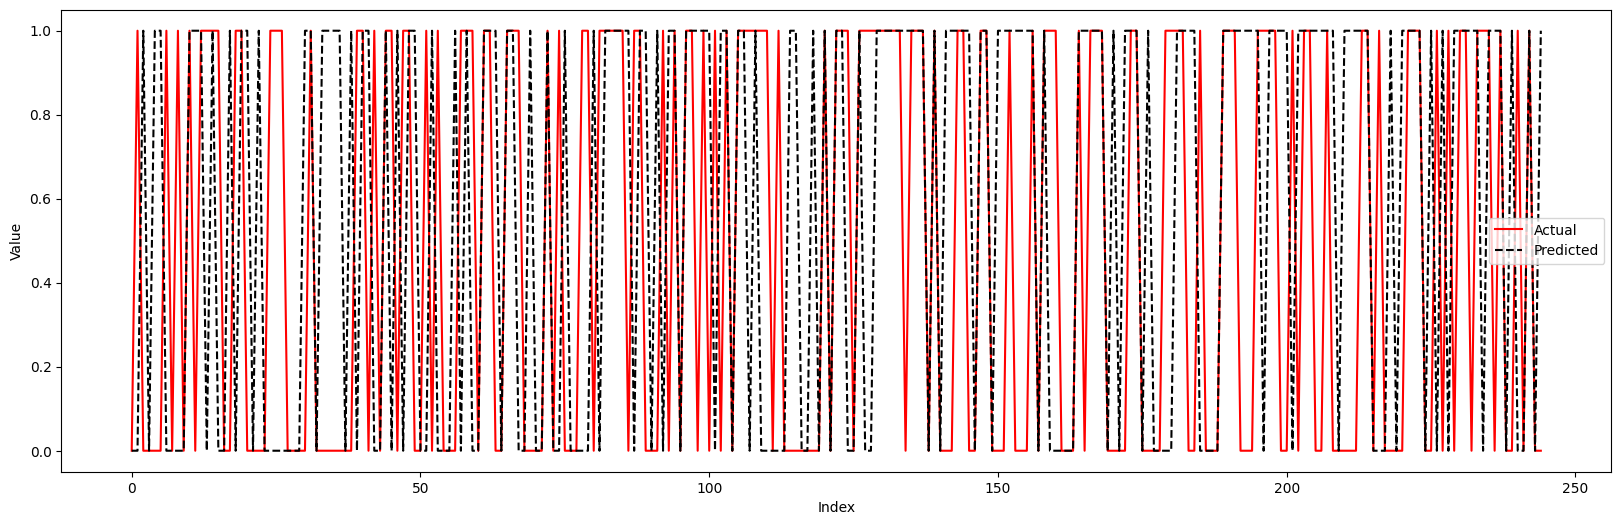

In [118]:
# Create an array of indices for the x-axis
x_values = np.arange(len(yg_test))

# Plot the actual values as a blue line
plt.plot(yg_test, label='Actual', color='red')

# Plot the predicted values as a red dashed line
plt.plot(y_pred, label='Predicted', linestyle='--', color='black')

# Add labels and legend
plt.xlabel('Index')
plt.ylabel('Value')
plt.legend()

# Show the plot
plt.show()

In [119]:
len(y_pred)

245

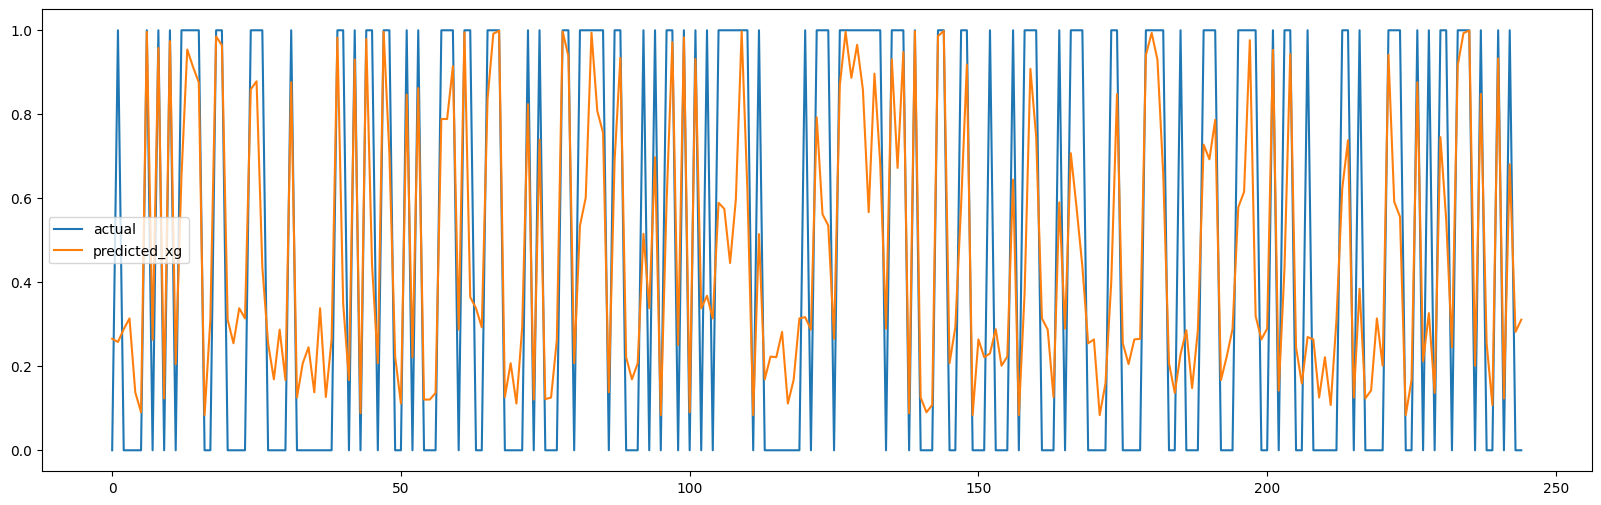

In [120]:
plt.plot(yg_test, label = 'actual')
plt.plot(yg_pred, label = 'predicted_xg')
plt.legend()

In [121]:
from sklearn.model_selection import GridSearchCV

#Hyperparameter tuning
params = {
    'min_child_weight': [4, 5],
    'gamma': [i / 10.0 for i in range(3, 6)],
    'subsample': [i / 10.0 for i in range(6, 11)],
    'colsample_bytree': [i / 10.0 for i in range(6, 11)],
    'max_depth': [2, 3, 4]
}
# Initialize XGB and GridSearch
xgb_reg = xgb.XGBRegressor(nthread=-1, objective='reg:squarederror')
grid = GridSearchCV(xgb_reg, params)
grid.fit(Xg_train, yg_train)
gridcv_xgb = grid.best_estimator_

In [122]:
print(R2(yg_test, gridcv_xgb.predict(Xg_test)))

0.767744660923445


In [123]:
yg_test_tuned=gridcv_xgb.predict(Xg_test)

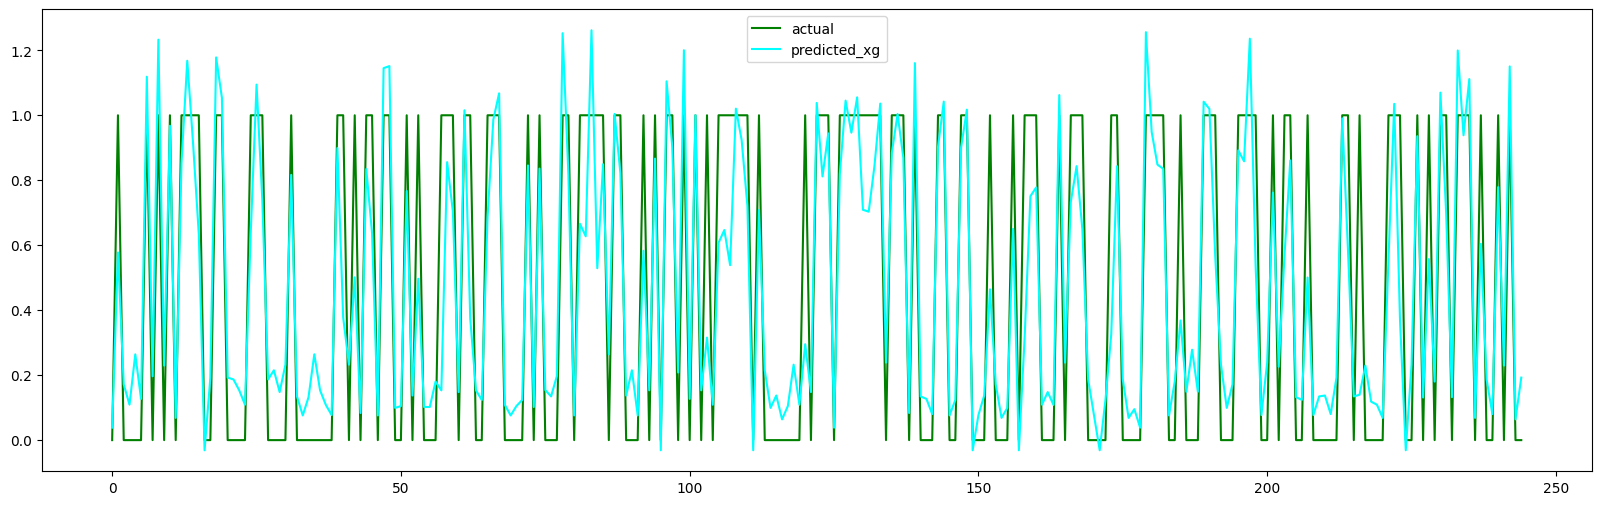

In [124]:
plt.plot(yg_test, label = 'actual', color='green')
plt.plot(yg_test_tuned, label = 'predicted_xg',  color='cyan')
plt.legend()